# Base-use 00 — The feature-space graph Laplacian, seen through `search()`

**Question.** Every `ArrowSpaceBuilder().build(params, items)` returns a **pair**: the
index `aspace` and a `GraphLaplacian` `gl` — and every search call takes `gl` again:
`aspace.search(q, gl, tau)`. What is this Laplacian a graph *of*, and what does the `tau`
dial actually do to rankings?

The bindings' `gl` is a **feature-space** Laplacian $L_F$: a $D \times D$ graph whose
nodes are the **embedding dimensions**, weighted by how the dataset makes them
co-vary — not an item-space adjacency. Per-item $\lambda\tau$ scores are Rayleigh-style
statistics computed through this wiring: items in spectrally coherent dimension regions
score low, rough/transitional items score high. A query must be $\lambda$-prepared against
the same graph before it can be ranked — hence `gl` as a search argument.

**Dataset.** `dataset/eigenmaps_controlled.parquet` — 1000 unit-norm items × 128
dimensions, three orthonormal clusters of increasing sparsity (pyarrowspace calibration
fixture). The dataset README prescribes `eps=0.5, sigma=0.5, k=12` (the pre-0.28 default
`eps=0.001` disconnects the graph and collapses every $\lambda\tau$ to 0 — the
quality-gate failure mode in the docs; 0.28.0 recalibrated its defaults to this regime). We recover the cluster labels in-notebook with k-means; nothing else
about the data is used, so every score below is an *unsupervised* ArrowSpace readout.

You will see:

1. $L_F$ at real scale: a 128-node dimension graph — heatmap, eigenvalue spectrum, Fiedler value.
2. $\lambda\tau$ as an unsupervised **sparsity detector**: rank-correlation $\approx -0.4$
   with each item's effective dimension count — with labels never shown to the index.
3. `tau` as the cosine $\leftrightarrow$ spectral blend: `tau=1.0` reproduces cosine
   exactly; as $\tau$ drops, the tail of the ranking becomes increasingly $\lambda\tau$-ordered.
4. The 0.27 error contract: catchable `ValueError`s for degenerate/non-finite/mismatched
   queries — and a Principle-0 caution against re-deriving $\lambda$ in NumPy.

### References
- ArrowSpace JOSS paper: https://doi.org/10.21105/joss.09002
- Dataset README + MIT license: `dataset/`
- Repo principles: `notebooks/README.md` (API scores only; $\lambda\tau$ is a final score)

## 0 · Imports, dataset, and the prescribed hyperparameters

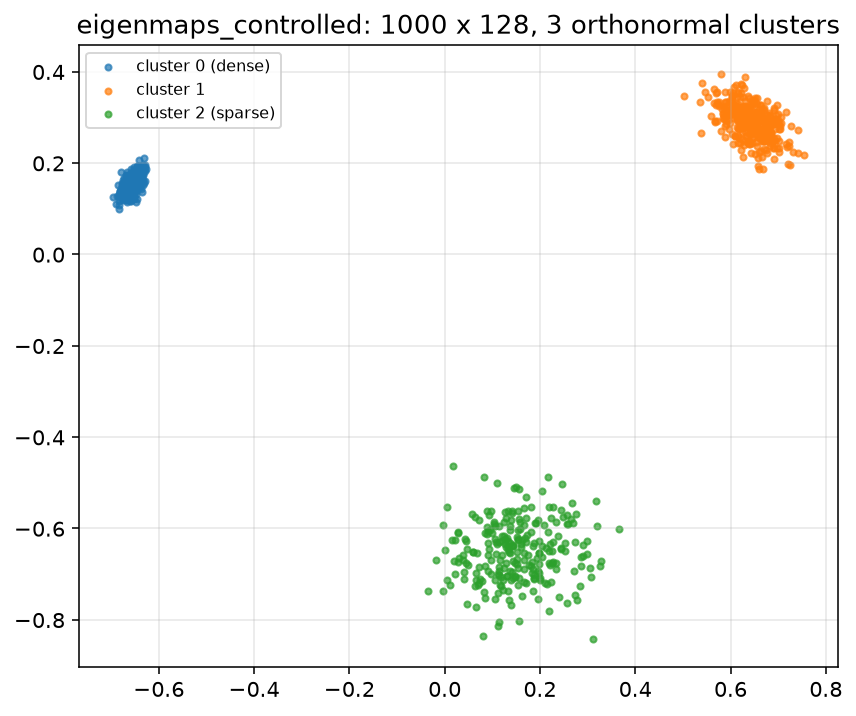

items: (1000, 128)  counts: [400, 350, 250]
cross-cluster cosine ~ -0.0022


In [1]:
import shutil
from pathlib import Path
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.stats import spearmanr
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from arrowspace import ArrowSpaceBuilder, sequence_by_lambda, sequence_by_graph

SEED = 42
DATA_PATH = Path("../dataset/eigenmaps_controlled.parquet")

plt.rcParams.update({
    "figure.dpi": 140, "font.size": 11, "axes.grid": True,
    "grid.alpha": 0.3, "figure.constrained_layout.use": True,
})

# The dataset README prescribes these graph parameters; the pre-0.28 defaults
# (eps=0.001) disconnect the unit-norm feature graph (every lambda ~ 0).
# Notably, 0.28.0's recalibrated defaults (eps=0.5, k=12) match this prescription.
# Reuse only, never regenerate.
GRAPH_PARAMS = {"eps": 0.5, "k": 12, "topk": 8, "p": 2.0, "sigma": 0.5}

X = np.ascontiguousarray(  # pyarrow/pandas slices may be non-contiguous; ArrowSpace asks for C-contiguous rows
    pq.read_table(DATA_PATH).to_pandas().to_numpy(np.float64)
)
N, D = X.shape
assert X.shape == (1000, 128) and np.allclose(np.linalg.norm(X, axis=1), 1.0)

# Ground truth: three orthonormal clusters. The shipped copy drops the `cluster`
# column; recover it from the data — the clusters are mutually orthogonal, so
# k-means (fixed seed) recovers them exactly. K-means labels are index-arbitrary, so
# we re-index clusters by mean effective-dimension count (dense -> sparse). This makes
# "cluster 2" always the sparsest, so later narrative/asserts about labels==2 are correct.
p2 = X ** 2
eff_dims = p2.sum(axis=1) ** 2 / np.sum(p2 ** 2, axis=1)   # participation ratio per item
_km = KMeans(3, n_init=10, random_state=SEED).fit_predict(X)
_dense_first = np.argsort([-eff_dims[_km == c].mean() for c in range(3)])
labels = np.empty_like(_km)
for _new, _old in enumerate(_dense_first):
    labels[_km == _old] = _new
NAMES = ["cluster 0 (dense)", "cluster 1", "cluster 2 (sparse)"]
COLORS = np.asarray(plt.get_cmap("tab10").colors)

def modal_share(ix):
    """Fraction of a motif's items belonging to one k-means cluster."""
    _, cnt = np.unique(labels[list(ix)], return_counts=True)
    return float(cnt.max() / len(ix))

xy = PCA(n_components=2, random_state=SEED).fit_transform(X)
fig, ax = plt.subplots(figsize=(6, 5))
for c in range(3):
    ax.scatter(xy[labels == c, 0], xy[labels == c, 1], s=10, alpha=0.7,
               color=COLORS[c], label=NAMES[c])
ax.legend(fontsize=8)
ax.set_title("eigenmaps_controlled: 1000 x 128, 3 orthonormal clusters")
OUT = Path("output__intro")
if OUT.exists():
    shutil.rmtree(OUT)                       # deterministic, clean output dir
OUT.mkdir(parents=True)
fig.savefig(OUT / "fig_01_dataset.png")
plt.show()

print(f"items: {X.shape}  counts: {np.bincount(labels).tolist()}")
print(f"cross-cluster cosine ~ {(X @ X.T)[labels[:, None] != labels[None, :]].mean():.4f}")

## 1 · The build returns an index *and* the wiring

`with_dims_reduction(False, None)` keeps the analysis honest: no Johnson–Lindenstrauss
projection between our 128 dimensions and $L_F$.

In [2]:
aspace, gl = (
    ArrowSpaceBuilder()
    .with_seed(SEED)
    .with_dims_reduction(False, None)
    .build(GRAPH_PARAMS, X)
)

lam = np.asarray(aspace.lambdas())
n_degenerate = int(np.sum(np.abs(lam) < 1e-12))

print(f"aspace: nitems={aspace.nitems}  nfeatures={aspace.nfeatures}  nclusters={aspace.nclusters}")
print(f"gl:     shape={gl.shape()}  nnodes={gl.nnodes}")
print(f"degenerate lambdas: {n_degenerate} / {len(lam)}   range: [{lam.min():.3f}, {lam.max():.3f}]")
assert gl.shape() == (D, D), "the exposed Laplacian is the feature-space L_F"
assert n_degenerate < 0.05 * len(lam), "index collapsed: the README's eps is not being honoured"
# Note: gl.nnodes reports the item count of the raw data, NOT the node count of
# gl.matrix (F x F over features) — the #165 namespace split; trust shape().

aspace: nitems=1000  nfeatures=128  nclusters=10
gl:     shape=(128, 128)  nnodes=1000
degenerate lambdas: 1 / 1000   range: [0.000, 1.000]


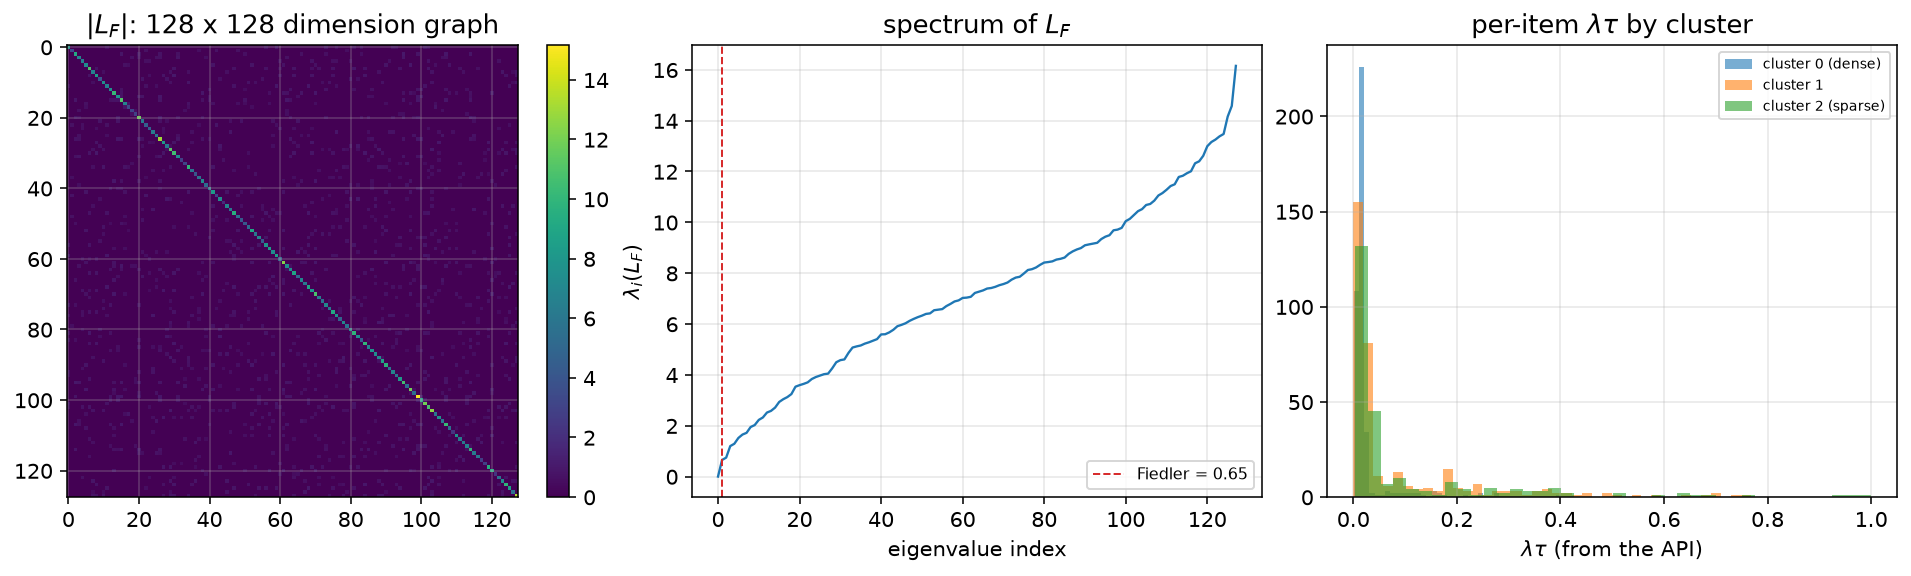

Fiedler value = 0.653  (well above 0.1: dimension graph is well wired)
mean lambda-tau per cluster (dense->sparse): [0.0239, 0.0856, 0.0992]  |  spearman(lambda-tau, eff-dims) = -0.387


In [3]:
# What is written on L_F at 128-node scale: the dimension graph and its spectrum.
L = np.asarray(gl.to_dense(), dtype=np.float64)
Lsym = (L + L.T) / 2
eig = np.sort(np.linalg.eigvalsh(Lsym))
fiedler = float(eig[1])

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
im = axes[0].imshow(np.abs(Lsym), cmap="viridis")
axes[0].set_title(r"$|L_F|$: 128 x 128 dimension graph")
fig.colorbar(im, ax=axes[0], fraction=0.046)

axes[1].plot(eig, lw=1.2)
axes[1].axvline(1, color="tab:red", ls="--", lw=1, label=f"Fiedler = {fiedler:.2f}")
axes[1].set_xlabel("eigenvalue index"); axes[1].set_ylabel(r"$\lambda_i(L_F)$")
axes[1].set_title("spectrum of $L_F$"); axes[1].legend(fontsize=8)

for c in range(3):
    axes[2].hist(lam[labels == c], bins=40, alpha=0.6, color=COLORS[c], label=NAMES[c])
axes[2].set_xlabel(r"$\lambda\tau$ (from the API)")
axes[2].set_title(r"per-item $\lambda\tau$ by cluster")
axes[2].legend(fontsize=7)
fig.savefig(OUT / "fig_02_laplacian_and_scores.png")
plt.show()

rho_sparsity = float(spearmanr(lam, eff_dims).statistic)
mean_lam = [round(float(lam[labels == c].mean()), 4) for c in range(3)]
print(f"Fiedler value = {fiedler:.3f}  (well above 0.1: dimension graph is well wired)")
print(f"mean lambda-tau per cluster (dense->sparse): {mean_lam}  |  "
      f"spearman(lambda-tau, eff-dims) = {rho_sparsity:.3f}")
assert mean_lam == sorted(mean_lam), "lambda-tau should rise monotonically with cluster sparsity"
assert rho_sparsity < -0.3, "lambda-tau should rise as items spread over fewer effective dims"

**Reading.** At $D=128$ the exposed Laplacian is a real graph with structure, not a
toy. Its Fiedler value (~0.65) says the dimension wiring is healthy; and the per-item
readout already *unsupervisedly* tracks the dataset's construction: the dense cluster
sits near $\lambda\tau \approx 0.02$ while the sparser clusters sit roughly four times higher,
with rank correlation $\approx -0.4$ against an item's effective dimension count. Coherent,
energy-spread items are spectrally smooth; sparse/rough items are not.

## 2 · `search(q, gl, tau)`: tau is the cosine $\leftrightarrow$ spectral dial

`tau` weights the geometric term; $1-\tau$ weights the spectral ($\lambda\tau$) term.
Passing `k=N` returns the full ranking, so we can *measure* what the blend does instead
of eyeballing top-3. With orthonormal clusters the retrieval window itself is stable
(the query's own basin wins on cosine at any tau) — the interesting motion is **in the
tail**, where ordering switches from geometric noise to the spectral curriculum.

In [4]:
X_feat = aspace.get_all_items()                   # features as stored by the index
q_idx = int(np.where(labels == 0)[0][5])
q = X[q_idx]
cos_scores = X_feat @ q                           # rows are unit-norm

TAUS = [1.0, 0.7, 0.5, 0.3, 0.1]
rows = []
for tau in TAUS:
    hits = aspace.search(q, gl, tau, k=N)         # k overrides build-time topk
    idx = np.array([i for i, _ in hits])
    scores = np.array([s for _, s in hits])
    assert np.all(np.diff(scores) <= 1e-12), "hits arrive best-first"
    tail = idx[100:]
    rows.append({
        "tau": tau,
        "top20 == cosine top20": int((idx[:20] == np.argsort(-cos_scores)[:20]).all()),
        "own-basin in top100": int((labels[idx[:100]] == 0).sum()),
        "overlap@100 with cosine": round(float(len(set(idx[:100]) & set(np.argsort(-cos_scores)[:100])) / 100), 3),
        "mean eff-dims in top100": round(float(eff_dims[idx[:100]].mean()), 1),
        "spearman(tail order, lambda-tau)": round(float(spearmanr(np.arange(len(tail)), lam[tail]).statistic), 3),
    })
df = pd.DataFrame(rows)
print(df.to_string(index=False))

 tau  top20 == cosine top20  own-basin in top100  overlap@100 with cosine  mean eff-dims in top100  spearman(tail order, lambda-tau)
 1.0                      1                  100                     1.00                     49.4                             0.288
 0.7                      0                  100                     0.80                     49.3                             0.497
 0.5                      0                  100                     0.69                     49.3                             0.565
 0.3                      0                  100                     0.55                     49.4                             0.619
 0.1                      0                  100                     0.41                     49.4                             0.747


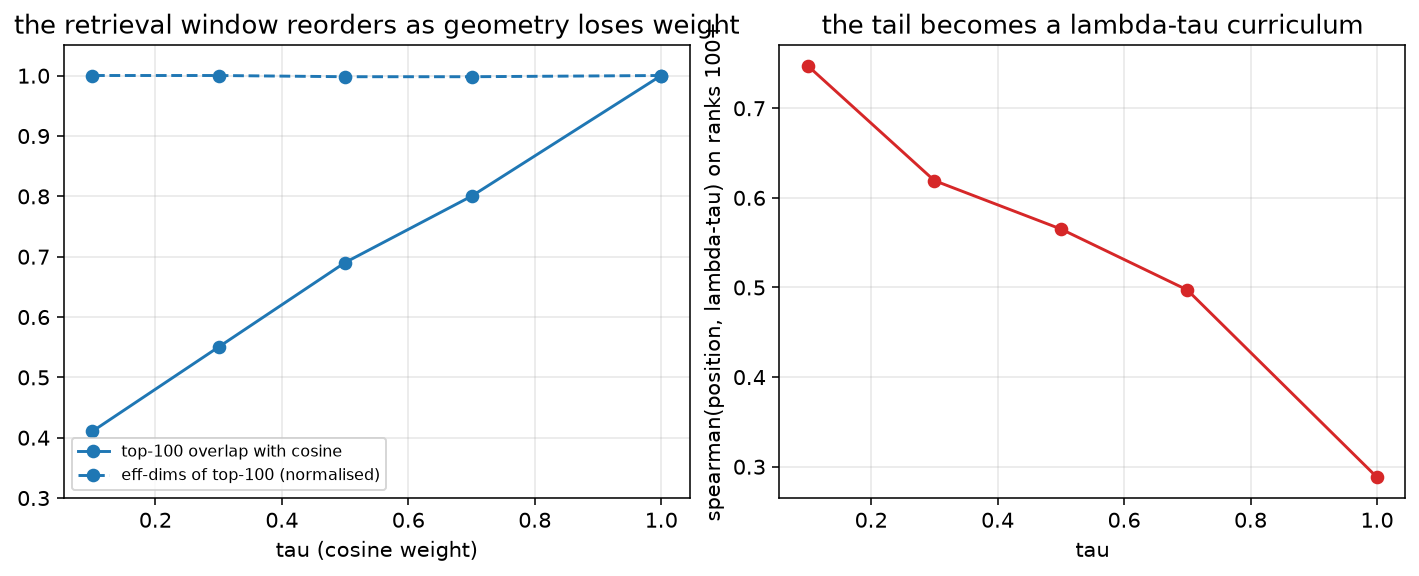

tau=1.0 reproduces cosine exactly; at tau=0.1 the post-window tail is lambda-ordered (rho=0.747). Own-basin retrieval held at 100/100 throughout — the blend cost was paid by the tail, not the window.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(df["tau"], df["overlap@100 with cosine"], "o-", color="tab:blue",
             label="top-100 overlap with cosine")
axes[0].plot(df["tau"], df["mean eff-dims in top100"] / df.loc[df.tau == 1.0, "mean eff-dims in top100"].iloc[0],
             "o--", color=COLORS[0], label="eff-dims of top-100 (normalised)")
axes[0].set_xlabel("tau (cosine weight)"); axes[0].set_ylim(0.3, 1.05)
axes[0].set_title("the retrieval window reorders as geometry loses weight")
axes[0].legend(fontsize=8)

axes[1].plot(df["tau"], df["spearman(tail order, lambda-tau)"], "o-", color="tab:red")
axes[1].set_xlabel("tau"); axes[1].set_ylabel("spearman(position, lambda-tau) on ranks 100+")
axes[1].set_title("the tail becomes a lambda-tau curriculum")
fig.savefig(OUT / "fig_03_tau_blend.png")
plt.show()

row1 = df.loc[df.tau == 1.0].iloc[0]
assert row1["top20 == cosine top20"] == 1, "tau=1 must equal cosine"
r_low = df.loc[df.tau == 0.1, "spearman(tail order, lambda-tau)"].iloc[0]
assert abs(r_low) > abs(row1["spearman(tail order, lambda-tau)"]), "spectral weight must order the tail"
print(f"tau=1.0 reproduces cosine exactly; at tau=0.1 the post-window tail is lambda-ordered "
      f"(rho={r_low}). Own-basin retrieval held at 100/100 throughout — the blend cost was paid "
      "by the tail, not the window.")

## 3 · Error contract and a Principle-0 caution

Queries go through `try_prepare_query_item` against the graph wiring, and every recoverable
failure surfaces as a catchable `ValueError` (0.27 typed errors — never a
`PanicException` crossing the FFI).

In [6]:
try:
    aspace.search(np.ones(3, dtype=np.float64), gl, 0.7)
except ValueError as e:
    print("wrong-dim query  ->", str(e)[:68])
try:
    aspace.search(np.full(D, np.nan), gl, 0.7)
except ValueError as e:
    print("non-finite query ->", str(e)[:68])

j = int(np.argmin(np.abs(lam)))                 # the dataset's one degenerate item
try:
    aspace.search(X[j], gl, 0.3)
except ValueError as e:
    print(f"degenerate-lambda item (index {j}, lambda={lam[j]:.1e}) -> {str(e)[:60]}...")

# Principle 0: manually Rayleigh-quotienting item vectors on the exposed L_F is a
# DIFFERENT object from the API's lambda-tau (which folds in the builder's internal
# item/centroid graph and the TauMode synthesis). Always read scores from the API.
R_manual = (X @ Lsym * X).sum(axis=1)           # unit-norm rows: x^T L x / x^T x = x^T L x
mad = float(np.mean(np.abs(R_manual - lam)))
rho = float(spearmanr(R_manual, lam).statistic)
print(f"manual x^T L_F x vs API lambda-tau: spearman = {rho:.3f},  mean abs diff = {mad:.3f}")
print("  -> not the same numbers; only the API's are the index's.")

wrong-dim query  -> dimension mismatch: expected 128 features, got 3
non-finite query -> query item contains non-finite values (NaN or Infinity)
degenerate-lambda item (index 555, lambda=0.0e+00) -> degenerate lambda (raw=0.000000): lambda is ~0.0, check the ...
manual x^T L_F x vs API lambda-tau: spearman = 0.382,  mean abs diff = 3.802
  -> not the same numbers; only the API's are the index's.


## 4 · Summary

In [7]:
summary = pd.DataFrame({
    "check": [
        "gl.shape equals (D, D) — feature-space L_F",
        "degenerate lambdas",
        "Fiedler value of L_F",
        "spearman(lambda-tau, eff-dims) — unsupervised sparsity detector",
        "tau=1.0 equals cosine top-20",
        "tail lambda-ordering at tau=0.1 (spearman)",
        "manual vs API score spearman / mean-abs-diff",
    ],
    "value": [
        str(gl.shape()),
        n_degenerate,
        round(fiedler, 3),
        round(rho_sparsity, 3),
        row1["top20 == cosine top20"],
        r_low,
        f"{rho:.3f} / {mad:.3f}",
    ],
})
summary.to_csv(OUT / "laplacian_intro_summary.csv", index=False)
print(summary.to_string(index=False))

                                                          check         value
                     gl.shape equals (D, D) — feature-space L_F    (128, 128)
                                             degenerate lambdas             1
                                           Fiedler value of L_F         0.653
spearman(lambda-tau, eff-dims) — unsupervised sparsity detector        -0.387
                                   tau=1.0 equals cosine top-20           1.0
                     tail lambda-ordering at tau=0.1 (spearman)         0.747
                   manual vs API score spearman / mean-abs-diff 0.382 / 3.802


**Reading.**

1. `build` hands you the dimension graph $L_F$ because queries must be $\lambda$-prepared
   against the same wiring; item ranking itself goes through the index's internal
   centroid graph plus the TauMode synthesis. `gl.shape()`, not `gl.nnodes`, is the
   Laplacian's true size.
2. `search(q, gl, tau)` is one honest knob: $\tau=1$ is audited cosine (bit-exact here);
   as $\tau\downarrow$ the blend reorders the tail into a $\lambda\tau$ curriculum
   (spearman 0.29 -> 0.75 here) while the retrieval window itself holds at 100/100 own
   basin — on orthonormal basins the blend cost lands in the tail, not the window.
3. Hyperparameters are load-bearing: the dataset README's `eps=0.5, sigma=0.5` is what
   keeps this unit-norm 128-dim graph connected. At the pre-0.28 default `eps=0.001`
   every $\lambda\tau$ collapses to 0 and no amount of `tau` tuning recovers a signal —
   which is exactly why 0.28.0 recalibrated its builder defaults to the README's regime.

**Caveats.** Single query, single seed, controlled fixture — tune the sweep (multiple
queries, tau grid, eps/k sensitivity) before drawing conclusions on your own embeddings.